# 09 - Final All-Asset Research Report

# Market Regime Detection Using HMM and Mixture of Experts

This is the final project report notebook.

It includes:

- S&P 500, NASDAQ, and NIFTY
- HMM-based regime detection
- Regime-aware Mixture of Experts
- Random Forest, XGBoost, LightGBM, and HistGradientBoosting comparisons
- Walk-forward validation
- Per-asset evaluation

## Core Research Question

> Do regime-aware expert models improve market direction prediction compared with a single model trained across all market states?

Short answer from this experiment:

> Yes. The Random Forest Soft-Gated MoE produced the strongest all-asset strategy Sharpe and improved over the Random Forest baseline in the all-asset walk-forward test.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
DATA_DIR = Path("../data/processed")

## 1. Load Project Outputs

In [2]:
features = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
regime_all = pd.read_csv(DATA_DIR / "regime_features_all_assets.csv", parse_dates=["Date"])
all_asset_summary = pd.read_csv(DATA_DIR / "all_asset_summary_metrics.csv")
all_asset_metrics = pd.read_csv(DATA_DIR / "all_asset_model_metrics.csv")
per_asset_metrics = pd.read_csv(DATA_DIR / "all_asset_per_asset_metrics.csv")
all_asset_predictions = pd.read_csv(DATA_DIR / "all_asset_predictions.csv", parse_dates=["Date"])

print("Features:", features.shape)
print("All-asset regimes:", regime_all.shape)
print("All-asset predictions:", all_asset_predictions.shape)

Features: (3694, 28)
All-asset regimes: (1641, 33)
All-asset predictions: (2508, 11)


## 2. Project Pipeline

```text
Market data
    ↓
Feature engineering
    ↓
HMM regime detection per asset
    ↓
Baseline model
    ↓
Regime-specific expert models
    ↓
Soft-gated Mixture of Experts
    ↓
Walk-forward evaluation
```

## 3. Dataset Overview

Assets included:

- `^GSPC`: S&P 500
- `^IXIC`: NASDAQ
- `^NSEI`: NIFTY 50

The first version used S&P 500 only. The final version expands to all three assets.

In [3]:
dataset_overview = (
    features
    .groupby("ticker")
    .agg(
        rows=("Date", "count"),
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        avg_daily_return=("return_1d", "mean"),
        annualized_volatility=("return_1d", lambda x: x.std() * np.sqrt(252)),
        worst_drawdown=("drawdown", "min"),
    )
)

dataset_overview

,rows,start_date,end_date,avg_daily_return,annualized_volatility,worst_drawdown
ticker,,,,,,
^GSPC,1404,2010-03-30,2025-11-25,0.000605,0.173403,-0.270410
^IXIC,1404,2010-03-30,2025-11-25,0.000735,0.208937,-0.355879
^NSEI,886,2010-05-27,2025-12-30,0.000446,0.137868,-0.200703


## 4. Feature Engineering Summary

Important features:

- **Return**: daily price change.
- **Volatility**: instability over recent days.
- **Momentum**: recent directional strength.
- **Moving average ratio**: price relative to trend.
- **Drawdown**: decline from previous peak.
- **VIX**: volatility/fear proxy.

These features are used by both HMM and expert classifiers.

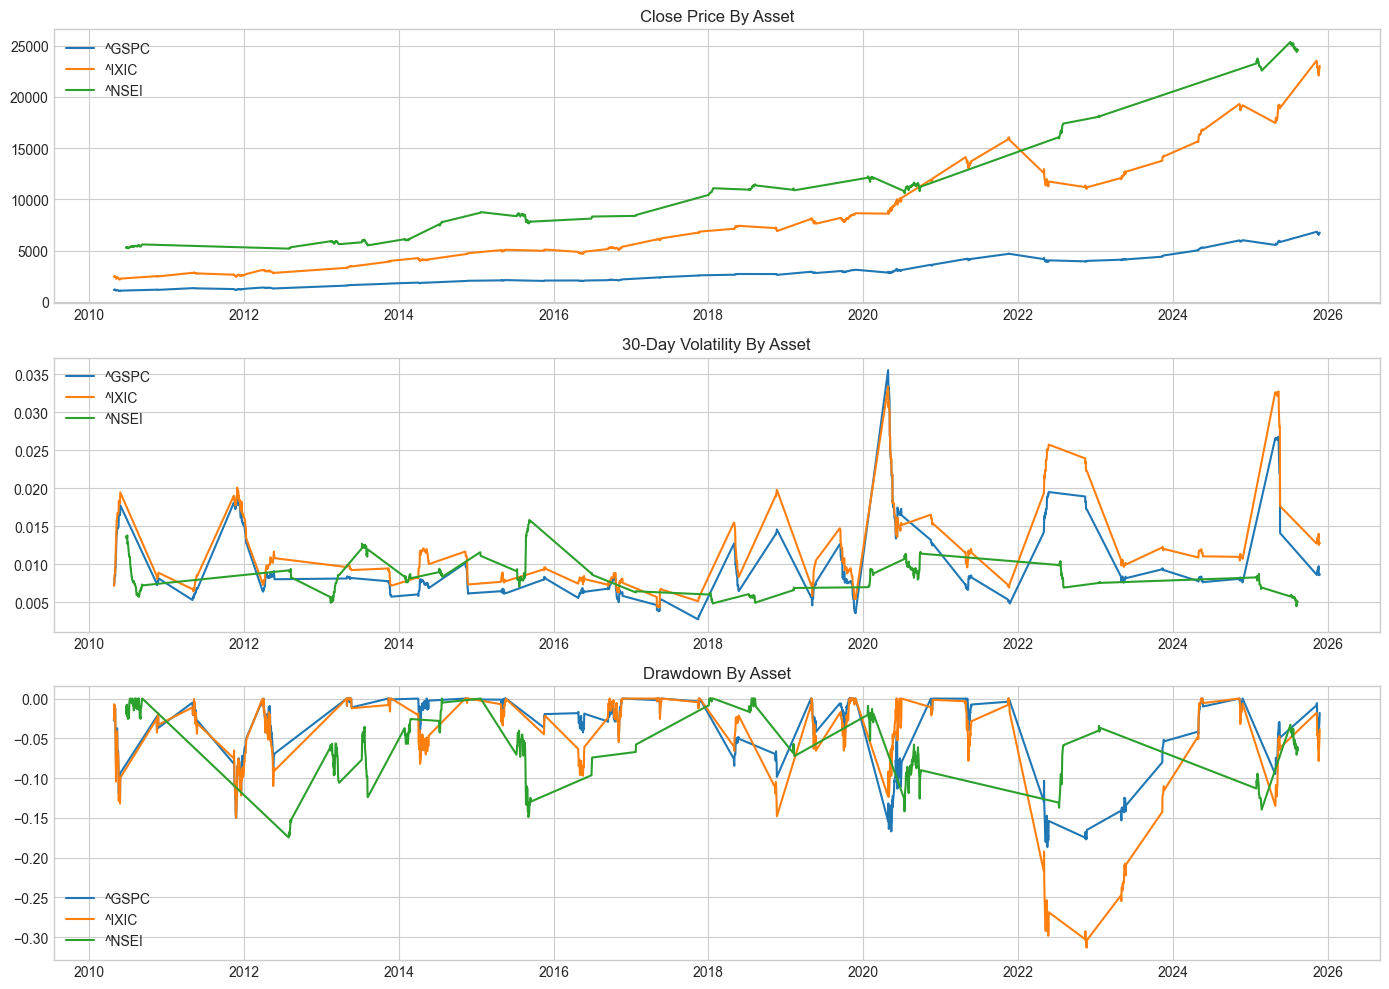

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ticker in regime_all["ticker"].unique():
    temp = regime_all[regime_all["ticker"] == ticker]
    axes[0].plot(temp["Date"], temp["Close"], label=ticker)

axes[0].set_title("Close Price By Asset")
axes[0].legend()

for ticker in regime_all["ticker"].unique():
    temp = regime_all[regime_all["ticker"] == ticker]
    axes[1].plot(temp["Date"], temp["volatility_30d"], label=ticker)

axes[1].set_title("30-Day Volatility By Asset")
axes[1].legend()

for ticker in regime_all["ticker"].unique():
    temp = regime_all[regime_all["ticker"] == ticker]
    axes[2].plot(temp["Date"], temp["drawdown"], label=ticker)

axes[2].set_title("Drawdown By Asset")
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. HMM Regime Detection

The HMM finds hidden market states from observable features.

The hidden states are interpreted as:

- Bull
- Bear
- Crisis

These labels are learned separately for each asset.

In [5]:
regime_summary = (
    regime_all
    .groupby(["ticker", "regime_label"])
    .agg(
        observations=("regime_label", "size"),
        avg_daily_return=("return_1d", "mean"),
        annualized_return=("return_1d", lambda x: x.mean() * 252),
        annualized_volatility=("return_1d", lambda x: x.std() * np.sqrt(252)),
        avg_drawdown=("drawdown", "mean"),
        worst_drawdown=("drawdown", "min"),
        avg_vix=("vix_close", "mean"),
    )
)

regime_summary

observations  avg_daily_return  annualized_return  \
ticker regime_label                                                      
^GSPC  Bear                   412          0.000237           0.059630   
       Bull                   118          0.000949           0.239130   
       Crisis                  93         -0.000260          -0.065461   
^IXIC  Bear                   415          0.000176           0.044405   
       Bull                   128          0.001832           0.461765   
       Crisis                  80         -0.000864          -0.217738   
^NSEI  Bear                   218          0.000267           0.067335   
       Bull                   122          0.001431           0.360683   
       Crisis                  55         -0.000690          -0.173800   

                     annualized_volatility  avg_drawdown  worst_drawdown  \
ticker regime_label                                                        
^GSPC  Bear                       0.112719     -0.014613       -0.062282   
       Bull                       0.191697     -0.095237       -0.177210   
       Crisis                     0.256518     -0.099125       -0.186753   
^IXIC  Bear                       0.148133     -0.024814       -0.110095   
       Bull                       0.252683     -0.070786       -0.150348   
       Crisis                     0.255740     -0.183632       -0.313433   
^NSEI  Bear                       0.123996     -0.042736       -0.124168   
       Bull                       0.127736     -0.054580       -0.141960   
       Crisis                     0.217314     -0.125218       -0.174838   

                       avg_vix  
ticker regime_label             
^GSPC  Bear          15.315607  
       Bull          23.779322  
       Crisis        26.606129  
^IXIC  Bear          15.421542  
       Bull          28.053437  
       Crisis        19.994750  
^NSEI  Bear          14.080092  
       Bull          25.138688  
       Crisis        21.481636

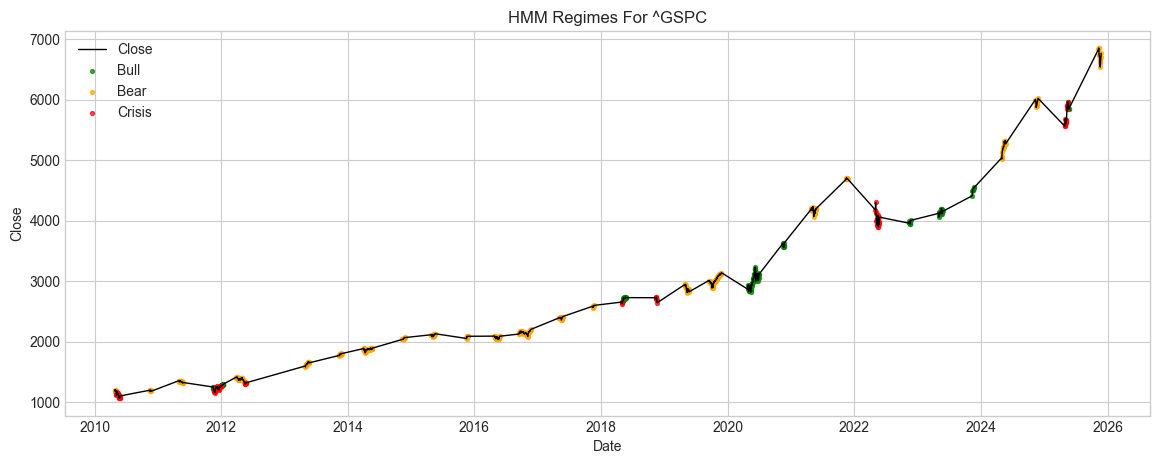

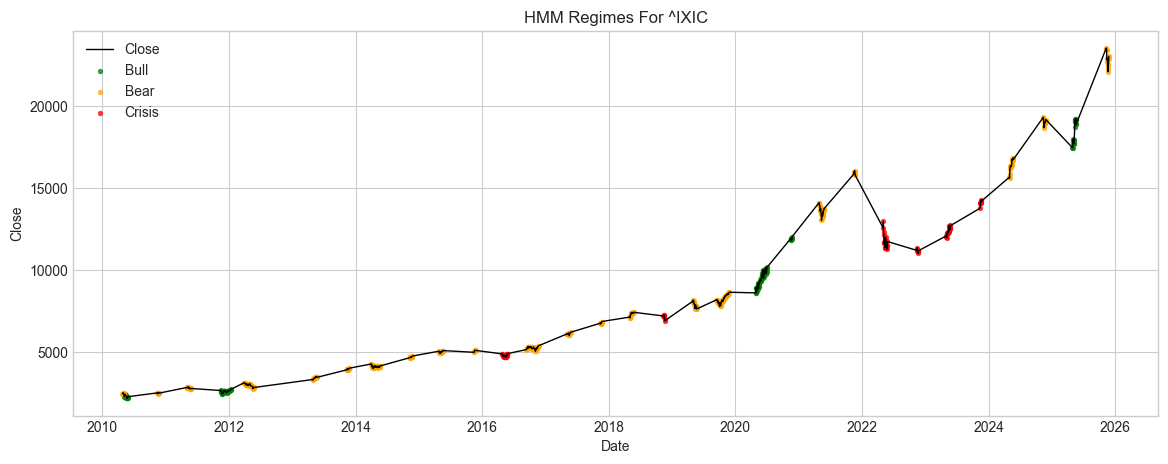

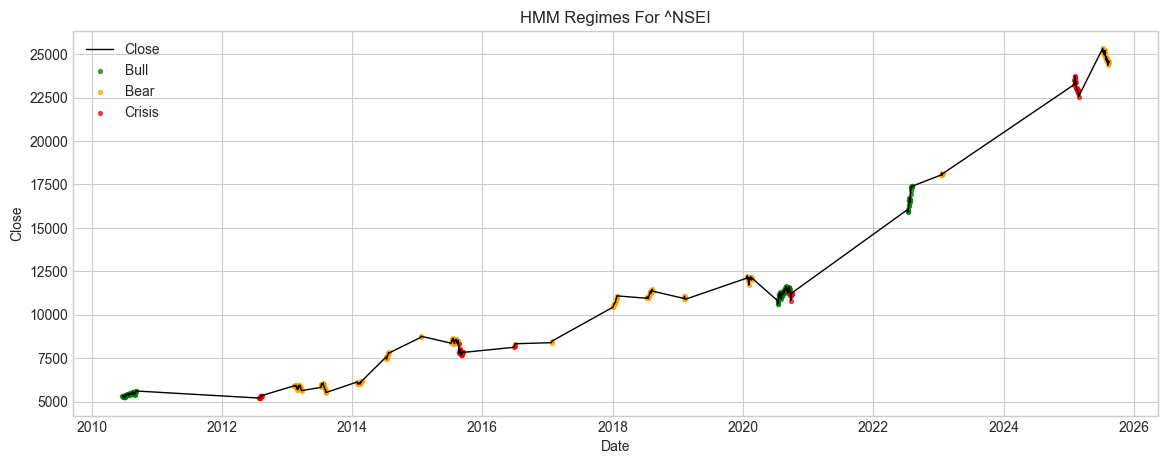

In [6]:
colors = {"Bull": "green", "Bear": "orange", "Crisis": "red"}

for ticker in regime_all["ticker"].unique():
    temp_asset = regime_all[regime_all["ticker"] == ticker]

    plt.figure(figsize=(14, 5))
    plt.plot(temp_asset["Date"], temp_asset["Close"], color="black", linewidth=1, label="Close")

    for label, color in colors.items():
        temp_regime = temp_asset[temp_asset["regime_label"] == label]
        plt.scatter(temp_regime["Date"], temp_regime["Close"], s=8, color=color, label=label, alpha=0.7)

    plt.title(f"HMM Regimes For {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.legend()
    plt.show()

## 6. All-Asset Model Comparison

Model families tested:

- Random Forest
- HistGradientBoosting
- XGBoost
- LightGBM

Routing methods:

- Baseline: one model trained on all regimes
- Hard MoE: use current regime's expert
- Soft MoE: weighted expert combination using HMM probabilities

In [7]:
all_asset_summary

,model_family,routing,folds,avg_accuracy,avg_precision,avg_recall,avg_f1,avg_roc_auc,avg_strategy_sharpe,avg_strategy_max_drawdown,avg_daily_strategy_return,avg_trade_rate
0,Random Forest,Soft MoE,3,0.539246,0.566443,0.788429,0.657083,0.477070,2.329324,-0.105726,0.001292,0.788437
1,LightGBM,Soft MoE,3,0.502931,0.554965,0.609377,0.576793,0.475840,2.184401,-0.080295,0.001057,0.620375
2,HistGradientBoosting,Soft MoE,3,0.500739,0.550650,0.618978,0.578342,0.493185,1.920017,-0.086826,0.000972,0.634340
3,Random Forest,Baseline,3,0.529234,0.552653,0.838517,0.662334,0.489288,1.917275,-0.127209,0.001088,0.852756
4,XGBoost,Soft MoE,3,0.509568,0.553793,0.661052,0.600340,0.476334,1.915268,-0.102792,0.000993,0.672785
5,LightGBM,Hard MoE,3,0.513084,0.557068,0.661474,0.600869,0.479914,1.848967,-0.092708,0.000985,0.668886
6,Random Forest,Hard MoE,3,0.526446,0.554651,0.785071,0.646923,0.485282,1.842102,-0.129421,0.001048,0.795867
7,HistGradientBoosting,Baseline,3,0.524136,0.564763,0.662078,0.604973,0.480471,1.778355,-0.101964,0.000877,0.660502
8,HistGradientBoosting,Hard MoE,3,0.507904,0.553641,0.665476,0.600667,0.494019,1.717451,-0.086514,0.000934,0.679202
9,XGBoost,Baseline,3,0.512137,0.547995,0.749623,0.628860,0.478131,1.707993,-0.143391,0.000906,0.770671


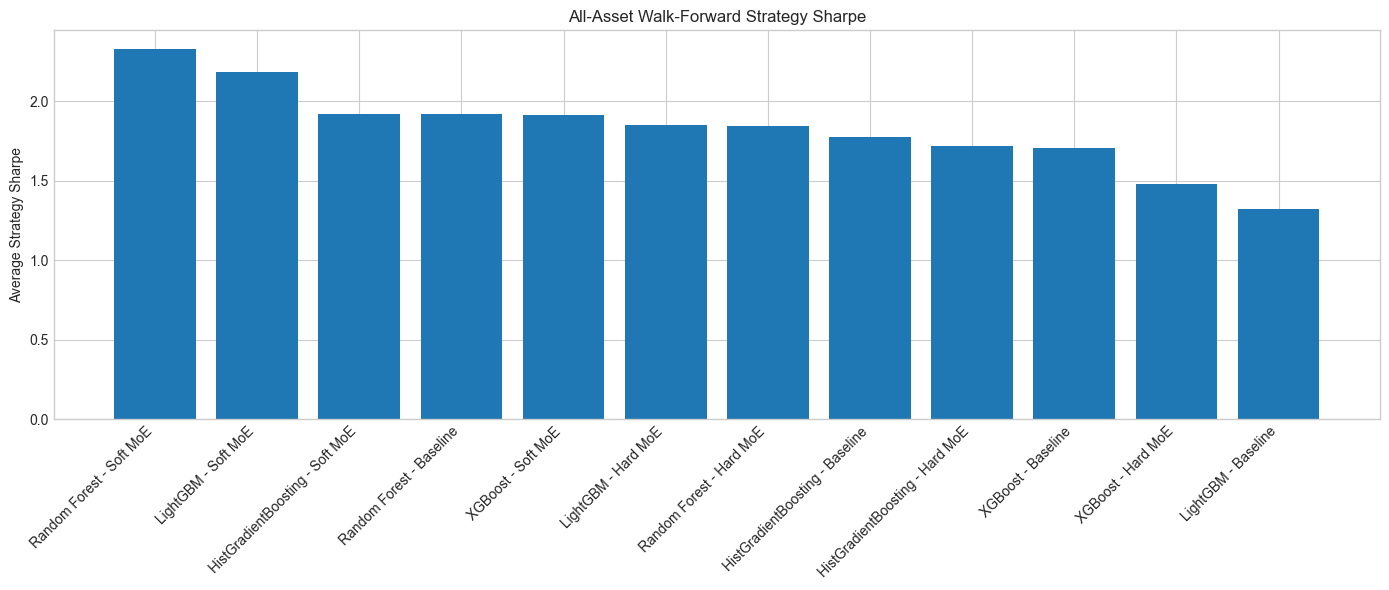

In [8]:
summary_plot = all_asset_summary.copy()
summary_plot["model"] = summary_plot["model_family"] + " - " + summary_plot["routing"]
summary_plot = summary_plot.sort_values("avg_strategy_sharpe", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(summary_plot["model"], summary_plot["avg_strategy_sharpe"])
plt.title("All-Asset Walk-Forward Strategy Sharpe")
plt.ylabel("Average Strategy Sharpe")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Best Result

The strongest model in the all-asset experiment was:

```text
Random Forest + Soft-Gated MoE
```

Key result:

- Higher strategy Sharpe than Random Forest baseline
- Lower drawdown than Random Forest baseline
- Better risk-adjusted performance across all assets

Boosted models were tested, but Random Forest Soft MoE remained the most stable on this dataset.

In [9]:
best_model = all_asset_summary.sort_values("avg_strategy_sharpe", ascending=False).head(1)
best_model

,model_family,routing,folds,avg_accuracy,avg_precision,avg_recall,avg_f1,avg_roc_auc,avg_strategy_sharpe,avg_strategy_max_drawdown,avg_daily_strategy_return,avg_trade_rate
0,Random Forest,Soft MoE,3,0.539246,0.566443,0.788429,0.657083,0.47707,2.329324,-0.105726,0.001292,0.788437


## 8. Per-Asset Performance

This checks whether the result is driven by only one asset or works across markets.

In [10]:
per_asset_metrics.sort_values(["ticker", "strategy_sharpe"], ascending=[True, False]).head(30)

,ticker,rows,accuracy,precision,recall,f1,strategy_sharpe,max_drawdown,avg_daily_return,trade_rate,model_family,routing
6,^GSPC,252.0,0.563492,0.595855,0.782313,0.676471,2.453180,-0.075633,0.001289,0.765873,Random Forest,Soft MoE
15,^GSPC,252.0,0.492063,0.570370,0.523810,0.546099,2.112661,-0.039150,0.000879,0.535714,HistGradientBoosting,Soft MoE
33,^GSPC,252.0,0.476190,0.559055,0.482993,0.518248,2.064918,-0.037530,0.000842,0.503968,LightGBM,Soft MoE
9,^GSPC,252.0,0.531746,0.601399,0.585034,0.593103,2.054621,-0.081734,0.000851,0.567460,HistGradientBoosting,Baseline
0,^GSPC,252.0,0.539683,0.575610,0.802721,0.670455,2.023481,-0.070737,0.001015,0.813492,Random Forest,Baseline
24,^GSPC,252.0,0.492063,0.563758,0.571429,0.567568,1.799988,-0.068318,0.000875,0.591270,XGBoost,Soft MoE
18,^GSPC,252.0,0.535714,0.582418,0.721088,0.644377,1.353103,-0.092875,0.000771,0.722222,XGBoost,Baseline
12,^GSPC,252.0,0.503968,0.567073,0.632653,0.598071,1.334242,-0.109973,0.000737,0.650794,HistGradientBoosting,Hard MoE
27,^GSPC,252.0,0.503968,0.570513,0.605442,0.587459,1.215682,-0.059341,0.000596,0.619048,LightGBM,Baseline
30,^GSPC,252.0,0.500000,0.566879,0.605442,0.585526,1.114219,-0.108549,0.000651,0.623016,LightGBM,Hard MoE


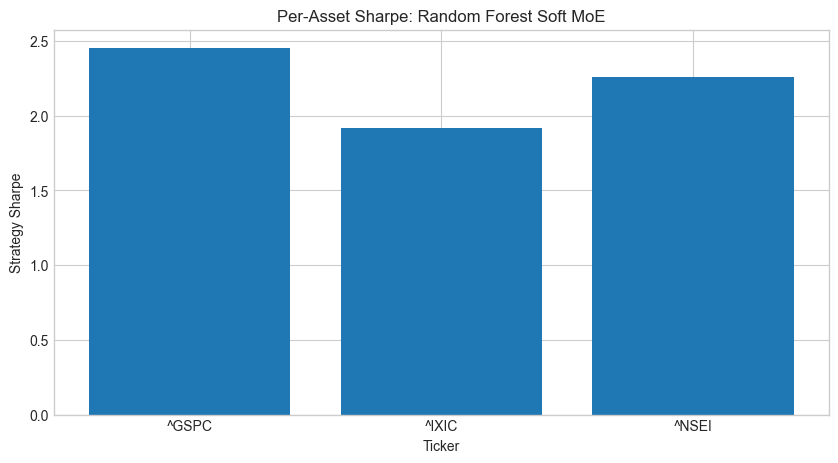

,ticker,rows,accuracy,precision,recall,f1,strategy_sharpe,max_drawdown,avg_daily_return,trade_rate,model_family,routing
6,^GSPC,252.0,0.563492,0.595855,0.782313,0.676471,2.453180,-0.075633,0.001289,0.765873,Random Forest,Soft MoE
7,^IXIC,252.0,0.511905,0.557292,0.737931,0.635015,1.920116,-0.105774,0.001317,0.761905,Random Forest,Soft MoE
8,^NSEI,123.0,0.536585,0.527273,0.920635,0.670520,2.258952,-0.061701,0.001260,0.894309,Random Forest,Soft MoE


In [11]:
best_family = best_model.iloc[0]["model_family"]
best_routing = best_model.iloc[0]["routing"]

best_per_asset = per_asset_metrics[
    (per_asset_metrics["model_family"] == best_family) &
    (per_asset_metrics["routing"] == best_routing)
]

plt.figure(figsize=(10, 5))
plt.bar(best_per_asset["ticker"], best_per_asset["strategy_sharpe"])
plt.title(f"Per-Asset Sharpe: {best_family} {best_routing}")
plt.ylabel("Strategy Sharpe")
plt.xlabel("Ticker")
plt.show()

best_per_asset

## 9. Equity Curves For Best Model

This compares buy-and-hold against the best all-asset MoE strategy.

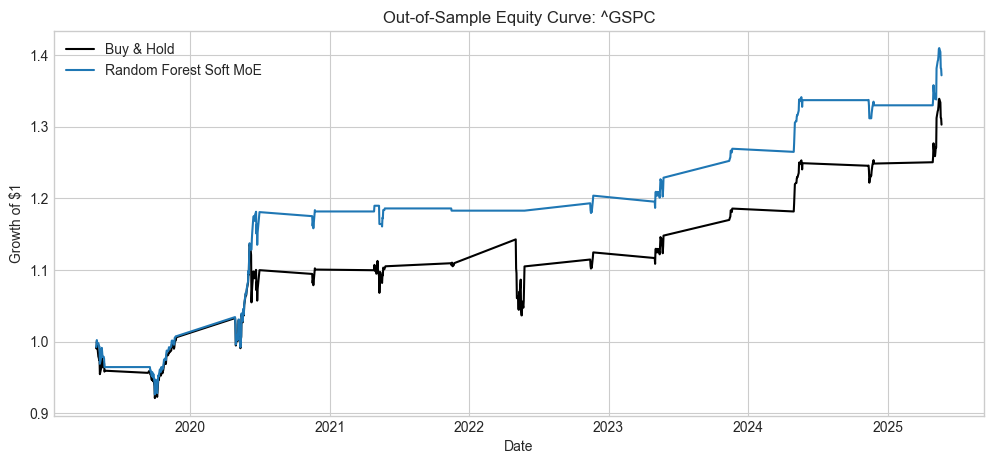

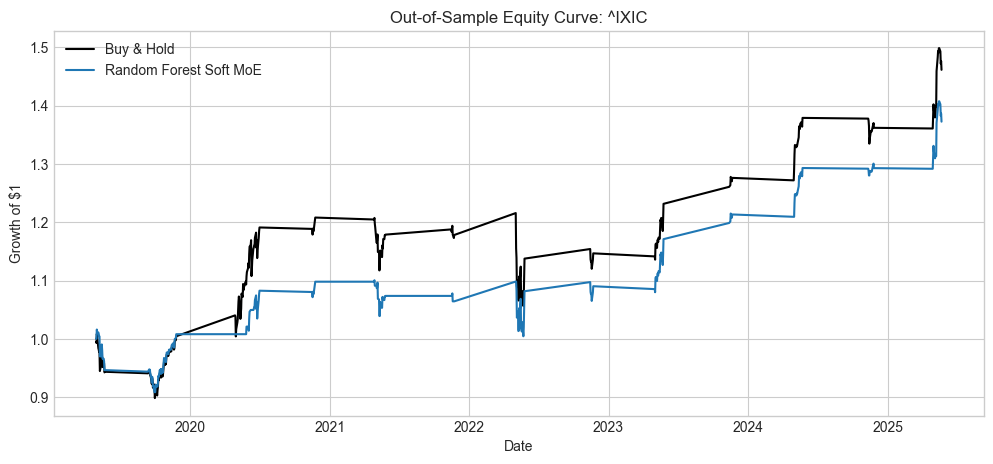

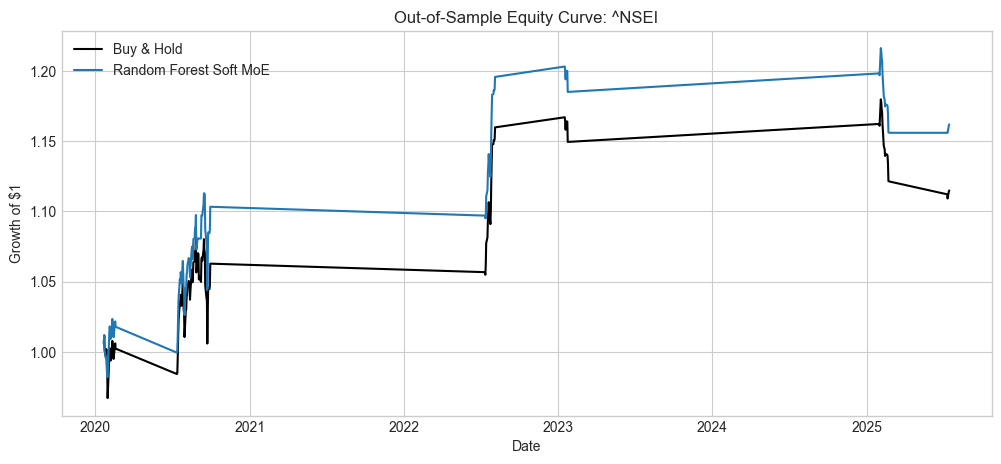

In [12]:
def strategy_returns(actual_returns, up_prob, threshold=0.45):
    signal = (np.asarray(up_prob) >= threshold).astype(int)
    return signal * np.asarray(actual_returns)

best_predictions = all_asset_predictions[all_asset_predictions["model_family"] == best_family].copy()
best_predictions = best_predictions.sort_values(["Date", "ticker"]).reset_index(drop=True)

if best_routing == "Baseline":
    prob_col = "baseline_up_prob"
elif best_routing == "Hard MoE":
    prob_col = "hard_moe_up_prob"
else:
    prob_col = "soft_moe_up_prob"

for ticker in best_predictions["ticker"].unique():
    temp = best_predictions[best_predictions["ticker"] == ticker].copy()
    temp = temp.sort_values("Date")

    buy_hold = (1 + temp["target_return_1d"]).cumprod()
    strategy = (1 + strategy_returns(temp["target_return_1d"], temp[prob_col], threshold=0.45)).cumprod()

    plt.figure(figsize=(12, 5))
    plt.plot(temp["Date"], buy_hold, label="Buy & Hold", color="black")
    plt.plot(temp["Date"], strategy, label=f"{best_family} {best_routing}")
    plt.title(f"Out-of-Sample Equity Curve: {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.show()

## 10. Final Findings

Final findings from the complete all-asset version:

1. HMMs can identify interpretable market regimes from return, volatility, momentum, drawdown, and VIX features.
2. Regime-aware MoE models can improve risk-adjusted performance versus a single baseline model.
3. The best all-asset result came from Random Forest Soft-Gated MoE.
4. XGBoost and LightGBM were tested, but did not outperform Random Forest on this dataset.
5. Multi-asset testing makes the project stronger than an S&P-only prototype.

## 11. Limitations

- Transaction costs and slippage are not included.
- HMM states are inferred, not externally labeled ground truth.
- NIFTY uses US VIX as a proxy in this version; India VIX would be a better extension.
- The dataset is still relatively small for deep learning.
- Hyperparameters are reasonable defaults, not exhaustively tuned.

## 12. Future Work

Strong future extensions:

1. Add India VIX for NIFTY.
2. Add macroeconomic features from FRED and RBI.
3. Add transaction costs and position sizing.
4. Use Bayesian HMM or Markov-switching models.
5. Build a neural gating network.
6. Add a transformer encoder using 60-day rolling sequences.
7. Convert this notebook pipeline into a clean Python package with scripts and tests.

## Resume Version

Project title:

**Market Regime Detection Using Hidden Markov Models and Mixture of Experts**

Resume bullet:

Built a multi-asset regime-aware financial ML system using HMMs to detect Bull, Bear, and Crisis states across S&P 500, NASDAQ, and NIFTY, then trained Mixture-of-Experts classifiers with Random Forest, XGBoost, and LightGBM baselines, improving walk-forward risk-adjusted performance over single-model baselines.